In [9]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [10]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [11]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [12]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='PIDMYE1.tcl',
                output_file='PIDMYE1',
                prefix="ops")

In [13]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (162458461507)>


In [14]:
ops.wipe()

# === PARAMETERIZED SOIL TYPES ===
soil_type = "silty_sand"  # options: silty_sand, soft_clay, dense_sand

soil_db = {
    "silty_sand": {
        "fmass": 1.0,
        "smass": 2.0,
        "G": 6.0e4,
        "B": 2.4e5,
        "bulk": 2.2e6,
        "vperm": 5.e-4,
        "hperm": 5.e-4,
    },
    "soft_clay": {
        "fmass": 1.0,
        "smass": 1.8,
        "G": 2.0e4,
        "B": 1.5e5,
        "bulk": 1.0e6,
        "vperm": 1.e-7,
        "hperm": 1.e-7,
    },
    "dense_sand": {
        "fmass": 1.0,
        "smass": 2.1,
        "G": 8.0e4,
        "B": 3.0e5,
        "bulk": 3.0e6,
        "vperm": 1.e-5,
        "hperm": 1.e-5,
    },
}

params = soil_db[soil_type]
fmass = params["fmass"]
smass = params["smass"]
G = params["G"]
B = params["B"]
bulk = params["bulk"]
vperm = params["vperm"] / 9.81 / fmass
hperm = params["hperm"] / 9.81 / fmass

# === WATER TABLE TRACKING ===

def is_node_below_water(y, water_table_elevation):
    return y <= water_table_elevation

water_table_y = 5.0  # meters, dynamic if needed per time step

accGravity = 9.81
press = 0.0
loadBias = 0.07
accMul = 2.0
accNam = "whatever.acc"
accDt = 0.0166
period = 1.0
deltaT = 0.01
numSteps = 2400
gamma = 0.6
massDamp = 0.0
stiffDamp = 0.002
numXele = 1
numYele = 10
xSize = 1.0
ySize = 1.0
matOpt = 1

ops.model('basic', '-ndm', 2, '-ndf', 3)

# Define material
ops.nDMaterial("PressureDependMultiYield", 1, 2, smass, G, B, 31.4, 0.1, 80, 0.5,
               26.5, 0.1, 0.2, 5, 10, 0.015, 1.0)

gravY = -accGravity
gravX = -gravY * loadBias

numXnode = numXele + 1
numYnode = numYele + 1

# Nodes
y_coords = {}
for i in range(1, numXnode + 1):
    for j in range(1, numYnode + 1):
        x = (i - 1) * xSize
        y = (j - 1) * ySize
        tag = i + (j - 1) * numXnode
        y_coords[tag] = y
        ops.node(tag, x, y)

# Elements
for i in range(1, numXele + 1):
    for j in range(1, numYele + 1):
        eleTag = i + (j - 1) * numXele
        n1 = i + (j - 1) * numXnode
        n2 = i + (j - 1) * numXnode + 1
        n4 = i + j * numXnode + 1
        n3 = i + j * numXnode
        ops.element("quadUP", eleTag, n1, n2, n4, n3, 1.0, matOpt, bulk, fmass, hperm, vperm, gravX, gravY, press)

# Set elastic stage
ops.updateMaterialStage('-material', matOpt, '-stage', 0)

# Fix base and apply drainage at surface
for i in range(1, numXnode + 1):
    ops.fix(i, 1, 1, 0)
    surfNode = (numYnode - 1) * numXnode + i
    ops.fix(surfNode, 0, 0, 1)

# Tie horizontal DOFs
for i in range(1, numYnode):
    n1 = i * numXnode + 1
    for j in range(2, numXnode + 1):
        n2 = i * numXnode + j
        ops.equalDOF(n1, n2, 1, 2)

# Gravity analysis
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1.0e-8, 25, 2)
ops.algorithm('Newton')
ops.constraints('Penalty', 1.e18, 1.e18)
ops.integrator('Newmark', 1.5, 1.0)
ops.analysis('Transient')
ops.analyze(3, 5.e3)

# Switch to plastic
ops.updateMaterialStage('-material', matOpt, '-stage', 1)
ops.analyze(5, 5.e3)

CTestNormDispIncr::test() - iteration: 6 current Norm: 3.63266e-10 (max: 1e-08, Norm deltaR: 1.02014)
CTestNormDispIncr::test() - iteration: 5 current Norm: 2.69937e-09 (max: 1e-08, Norm deltaR: 0.425652)
CTestNormDispIncr::test() - iteration: 4 current Norm: 7.38187e-09 (max: 1e-08, Norm deltaR: 1.07464)
CTestNormDispIncr::test() - iteration: 19 current Norm: 7.32742e-09 (max: 1e-08, Norm deltaR: 0.813703)
CTestNormDispIncr::test() - iteration: 17 current Norm: 6.66076e-09 (max: 1e-08, Norm deltaR: 0.835392)
CTestNormDispIncr::test() - iteration: 16 current Norm: 6.94239e-09 (max: 1e-08, Norm deltaR: 0.750197)
CTestNormDispIncr::test() - iteration: 15 current Norm: 4.99861e-09 (max: 1e-08, Norm deltaR: 0.612832)
CTestNormDispIncr::test() - iteration: 13 current Norm: 6.91512e-09 (max: 1e-08, Norm deltaR: 0.888203)


0

In [15]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [16]:
ops.wipeAnalysis()
ops.setTime(0.0)

# Excitation pattern
ops.timeSeries('Sine', 1, 0.0, 10.0, period, "-factor", accMul)
ops.pattern("UniformExcitation", 1, 1, "-accel",1)

# Recorders
nodeList = [int(numXnode / 2 + i * numXnode) for i in range(numYnode)]
ops.recorder('Node', '-file', 'disp', '-time', '-node', *nodeList, '-dof', 1, 2, '-dT', deltaT, 'disp')
ops.recorder('Node', '-file', 'pwp', '-time', '-node', *nodeList, '-dof', 3, '-dT', deltaT, 'vel')
ops.recorder('Node', '-file', 'acc', '-time', '-node', *nodeList, '-dof', 1, 2, '-dT', deltaT, 'accel')

for i in range(1, numYele):
    ele = numXele - numXele // 2 + (i - 1) * numXele
    ops.recorder('Element', '-ele', ele, '-time', '-file', f"stress{i}", '-dT', deltaT, 'material', 1, 'stress')
    ops.recorder('Element', '-ele', ele, '-time', '-file', f"strain{i}", '-dT', deltaT, 'material', 1, 'strain')

# Transient analysis
ops.constraints('Penalty', 1.e18, 1.e18)
ops.test('NormDispIncr', 1.e-5, 25, 0)
ops.numberer('RCM')
ops.algorithm('Newton')
ops.system('ProfileSPD')
ops.rayleigh(massDamp, 0.0, stiffDamp, 0.0)
beta = (gamma + 0.5)**2 / 4
ops.integrator('Newmark', gamma, beta)
ops.analysis('VariableTransient')

startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 15)
endT = tt.time()

print(f"Execution time: {int(endT - startT)} seconds.")

ops.wipe()

after: 25 iterations  current Norm: 0.000212546 (max: 1e-05, Norm deltaR: 0.662196)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 1.18587e-05 (max: 1e-05, Norm deltaR: 34.5789)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.000708552 (max: 1e-05, Norm deltaR: 47.2167)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.00132549 (max: 1e-05, Norm deltaR: 43.7108)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 5.91158e-05 (max: 1e-05, Norm deltaR: 86.9718)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 3.76614e-05 (max: 1e-05, Norm deltaR: 49.5706)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  curren

Execution time: 6 seconds.


after: 25 iterations  current Norm: 1.22232e-05 (max: 1e-05, Norm deltaR: 202.702)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.000683522 (max: 1e-05, Norm deltaR: 483.241)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.000190582 (max: 1e-05, Norm deltaR: 192.732)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.00024202 (max: 1e-05, Norm deltaR: 372.899)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()


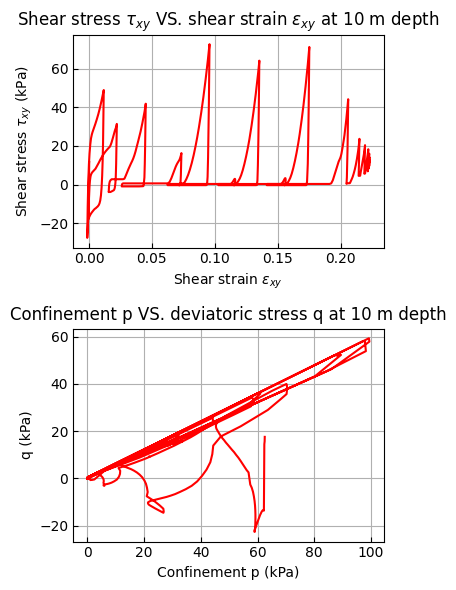

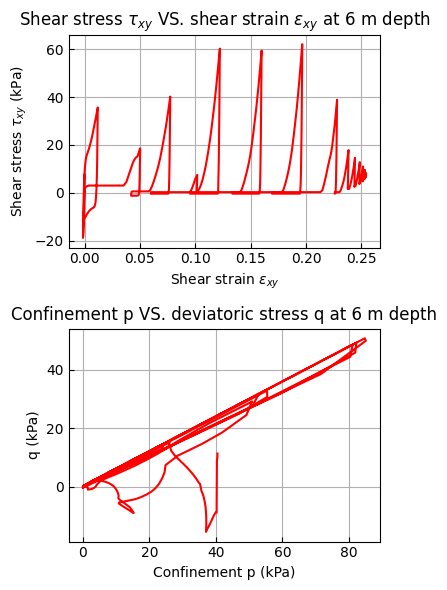

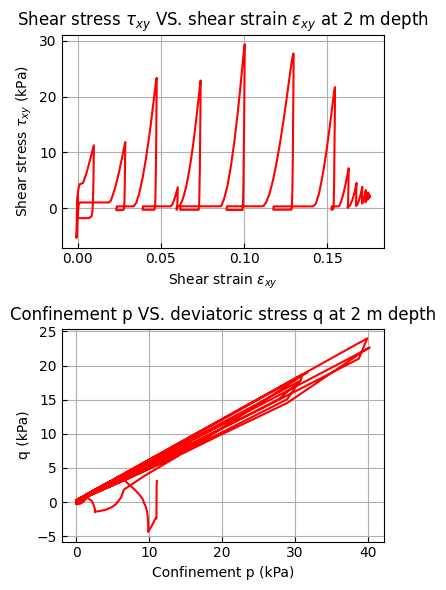

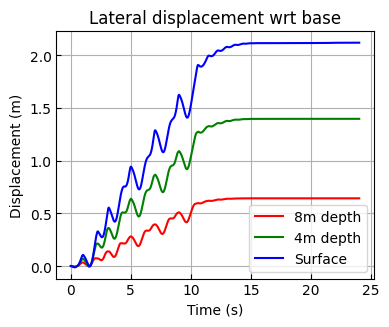

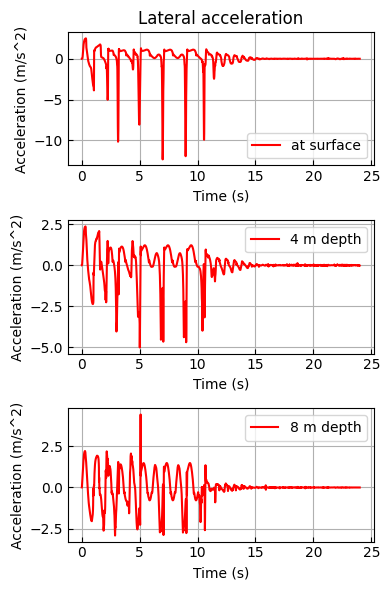

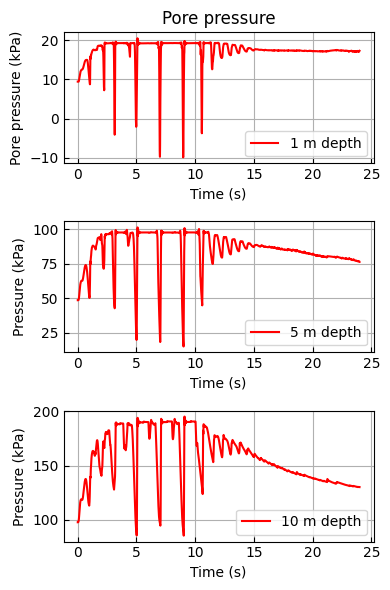

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the data from files ---
# In Python, we typically use numpy.loadtxt for text files,
# assuming they are space or comma-separated.
# The `unpack=True` argument can be used to unpack the columns into separate variables,
# but we'll stick to loading the full matrix for clarity.
a1 = np.loadtxt('acc')
d1 = np.loadtxt('disp')
p1 = np.loadtxt('pwp')
s1 = np.loadtxt('stress2')
e1 = np.loadtxt('strain2')
s5 = np.loadtxt('stress5')
e5 = np.loadtxt('strain5')
s9 = np.loadtxt('stress9')
e9 = np.loadtxt('strain9')

# Define global variables
fs = [0.5, 0.2, 4, 6]  # [left, bottom, width, height] for paperposition
accMul = 2

# --- 2. Helper function for p-q calculations and plotting ---
# This function helps to avoid repeating the same plotting code.
def plot_stress_strain_and_pq(stress_data, strain_data, figure_num, depth, filename):
    """
    Plots the shear stress vs. shear strain and confinement vs. deviatoric stress.

    Parameters:
    - stress_data (np.ndarray): The stress data matrix.
    - strain_data (np.ndarray): The strain data matrix.
    - figure_num (int): The figure number for the plot.
    - depth (str): A string representing the depth for the plot titles.
    - filename (str): The base name for saving the figure.
    """
    # Calculate p (mean normal stress)
    po = (stress_data[:, 1] + stress_data[:, 2] + stress_data[:, 3]) / 3.0

    # Calculate q (deviatoric stress)
    # The MATLAB code uses a loop, but we can do this with a single
    # vectorized operation in NumPy, which is much more efficient.
    term1 = (stress_data[:, 1] - stress_data[:, 2])**2
    term2 = (stress_data[:, 2] - stress_data[:, 3])**2
    term3 = (stress_data[:, 1] - stress_data[:, 3])**2
    term4 = 6.0 * stress_data[:, 4]**2
    qo = np.sqrt(term1 + term2 + term3 + term4) / 3.0
    
    # Apply the sign of s_xy (stress_data[:, 4]) to qo
    qo = np.sign(stress_data[:, 4]) * qo

    # Create the figure and subplots
    plt.figure(figure_num, figsize=(fs[2], fs[3])) # The 'figsize' parameter replaces MATLAB's 'paperposition'
    plt.clf()  # Clear the current figure before plotting
    
    # Subplot 1: Shear stress vs. shear strain
    plt.subplot(2, 1, 1)
    plt.plot(strain_data[:, 3], stress_data[:, 4], 'r')
    plt.title(f'Shear stress $\\tau_{{xy}}$ VS. shear strain $\\epsilon_{{xy}}$ at {depth} depth')
    plt.xlabel('Shear strain $\\epsilon_{{xy}}$')
    plt.ylabel('Shear stress $\\tau_{{xy}}$ (kPa)')
    plt.grid(True)

    # Subplot 2: Confinement vs. deviatoric stress
    plt.subplot(2, 1, 2)
    plt.plot(-po, qo, 'r')
    plt.title(f'Confinement p VS. deviatoric stress q at {depth} depth')
    plt.xlabel('Confinement p (kPa)')
    plt.ylabel('q (kPa)')
    plt.grid(True)
    
    plt.tight_layout() # Adjusts subplot parameters for a tight layout
    
    # Save the figure
    plt.savefig(f'{filename}.jpg', dpi=300)

# --- 3. Plotting the data for different integration points ---
# Call the helper function for each integration point
plot_stress_strain_and_pq(s1, e1, 1, '10 m', 'SS_PQ_10m')
plot_stress_strain_and_pq(s5, e5, 5, '6 m', 'SS_PQ_6m')
plot_stress_strain_and_pq(s9, e9, 6, '2 m', 'SS_PQ_2m')

# --- 4. Plotting displacement data ---
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 7], 'r', label='8m depth')
plt.plot(d1[:, 0], d1[:, 13], 'g', label='4m depth')
plt.plot(d1[:, 0], d1[:, 21], 'b', label='Surface')
plt.title('Lateral displacement wrt base')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Disp.jpg', dpi=300)

# --- 5. Plotting acceleration data ---
plt.figure(3, figsize=(fs[2], fs[3]))
plt.clf()

# Interpolate the sine wave
# MATLAB's interp1 is similar to scipy.interpolate.interp1d, but we can
# also manually create the sine wave and use numpy's interpolation function.
# Here, we'll replicate the MATLAB logic with NumPy.
t_sine = np.arange(0, 40.01, 0.01) # a1(:,1) is time, let's assume it starts at 0
s_wave = accMul * np.sin(np.arange(0, 20*np.pi + 1e-9, np.pi/50))
s_padded = np.pad(s_wave, (0, 3000), 'constant')
s_interpolated = np.interp(a1[:, 0], t_sine[:len(s_padded)], s_padded)

# Subplot 1: Surface acceleration
plt.subplot(3, 1, 1)
plt.plot(a1[:, 0], s_interpolated + a1[:, 21], 'r', label='at surface')
plt.title('Lateral acceleration')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

# Subplot 2: 4 m depth acceleration
plt.subplot(3, 1, 2)
plt.plot(a1[:, 0], s_interpolated + a1[:, 13], 'r', label='4 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

# Subplot 3: 8 m depth acceleration
plt.subplot(3, 1, 3)
plt.plot(a1[:, 0], s_interpolated + a1[:, 7], 'r', label='8 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('Acc.jpg', dpi=300)


# --- 6. Plotting pore pressure data ---
plt.figure(4, figsize=(fs[2], fs[3]))
plt.clf()

# Subplot 1: 1 m depth
plt.subplot(3, 1, 1)
plt.plot(p1[:, 0], p1[:, 10], 'r', label='1 m depth')
plt.title('Pore pressure')
plt.xlabel('Time (s)')
plt.ylabel('Pore pressure (kPa)')
plt.legend()
plt.grid(True)

# Subplot 2: 5 m depth
plt.subplot(3, 1, 2)
plt.plot(p1[:, 0], p1[:, 6], 'r', label='5 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (kPa)')
plt.legend()
plt.grid(True)

# Subplot 3: 10 m depth
plt.subplot(3, 1, 3)
plt.plot(p1[:, 0], p1[:, 1], 'r', label='10 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (kPa)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('EPWP.jpg', dpi=300)

plt.show() # Display all generated plots